In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "1ABZ": "CleanB/MOT-Bfield-1ABZ-C.csv",
    "1ABZ post": "CleanB/MOT-Bfield-1ABZ-post-C.csv",
    "1ABZ inverse": "CleanB/MOT-Bfield-1ABZinverse-C.csv",
    "1ABZ close": "CleanB/MOT-Bfield-1ABZClose-C.csv",
    "1ABZ top coil": "CleanB/MOT-Bfield-1ABZTopCoil-C.csv",
    "1ABZ bottom coil": "CleanB/MOT-Bfield-1ABZBottomCoil-C.csv",
    "3ABZ": "CleanB/MOT-Bfield-3ABZ-C.csv",
    "1ABX": "CleanB/MOT-Bfield-1ABX-C.csv",
}

In [2]:
data = {}

for name, file_path in files.items():
    df = pd.read_csv(file_path)

    # Remove accidental spaces from column names
    df.columns = df.columns.str.strip()

    data[name] = df

    print(f"\n{name}")
    print("Columns:", df.columns.tolist())
    print(df.head())



1ABZ
Columns: ['z(m)', 'B(G)']
       z(m)  B(G)
0 -0.249399   0.2
1 -0.247395   0.2
2 -0.245390   0.2
3 -0.243386   0.1
4 -0.241382   0.2

1ABZ post
Columns: ['z(m)', 'B(G)']
       z(m)  B(G)
0 -0.249399   0.1
1 -0.247395   0.0
2 -0.245390   0.0
3 -0.243386   0.1
4 -0.241382  -0.2

1ABZ inverse
Columns: ['z(m)', 'B(G)']
       z(m)  B(G)
0 -0.249399  -0.1
1 -0.247395   0.0
2 -0.245390   0.0
3 -0.243386   0.0
4 -0.241382  -0.1

1ABZ close
Columns: ['z(m)', 'B(G)']
       z(m)  B(G)
0 -0.197286   0.0
1 -0.196283   0.2
2 -0.195281   0.0
3 -0.194279   0.0
4 -0.193277   0.0

1ABZ top coil
Columns: ['z(m)', 'B(G)']
       z(m)  B(G)
0 -0.022906   0.0
1 -0.020901   0.2
2 -0.018897   0.2
3 -0.016893   0.3
4 -0.014888   0.3

1ABZ bottom coil
Columns: ['z(m)', 'B(G)']
       z(m)  B(G)
0 -0.173233   0.1
1 -0.171229   0.1
2 -0.169224   0.0
3 -0.167220   0.0
4 -0.165216   0.0

3ABZ
Columns: ['z(m)', 'B(G)']
       z(m)  B(G)
0 -0.249399  -0.1
1 -0.247395  -0.1
2 -0.245390   0.1
3 -0.243386  -0.

In [3]:
z_1ABZ = data["1ABZ"]["z(m)"]
B_1ABZ = data["1ABZ"]["B(G)"]

z_1ABZ_post = data["1ABZ post"]["z(m)"]
B_1ABZ_post = data["1ABZ post"]["B(G)"]

z_1ABZ_inverse = data["1ABZ inverse"]["z(m)"]
B_1ABZ_inverse = data["1ABZ inverse"]["B(G)"]

z_1ABZ_close = data["1ABZ close"]["z(m)"]
B_1ABZ_close = data["1ABZ close"]["B(G)"]

z_1ABZ_top = data["1ABZ top coil"]["z(m)"]
B_1ABZ_top = data["1ABZ top coil"]["B(G)"]

z_1ABZ_bottom = data["1ABZ bottom coil"]["z(m)"]
B_1ABZ_bottom = data["1ABZ bottom coil"]["B(G)"]

z_3ABZ = data["3ABZ"]["z(m)"]
B_3ABZ = data["3ABZ"]["B(G)"]

x_1ABX = data["1ABX"]["x(m)"]
B_1ABX = data["1ABX"]["B(G)"]

## B and B+Post comparison

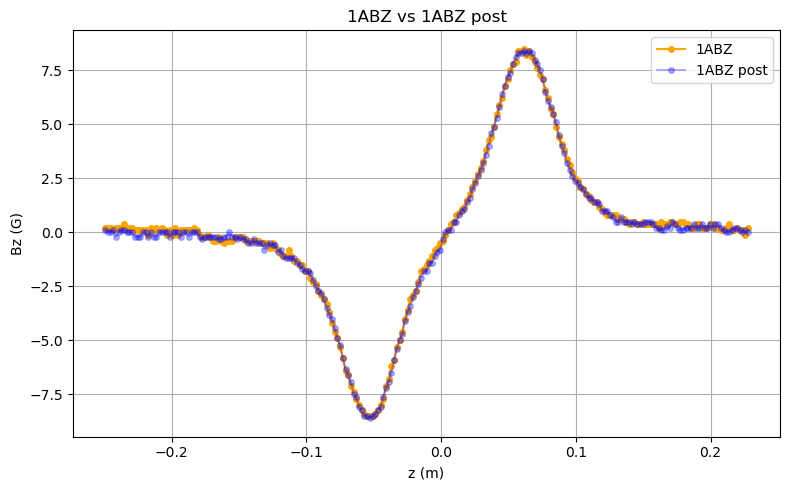

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(
    z_1ABZ,
    B_1ABZ,
    marker="o",
    markersize=4,
    color="orange",
    label="1ABZ"
)

plt.plot(
    z_1ABZ_post,
    B_1ABZ_post,
    marker="o",
    markersize=4,
    color="blue",
    alpha=0.3,
    label="1ABZ post"
)

plt.xlabel("z (m)")
plt.ylabel("Bz (G)")
plt.title("1ABZ vs 1ABZ post")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Inverse current

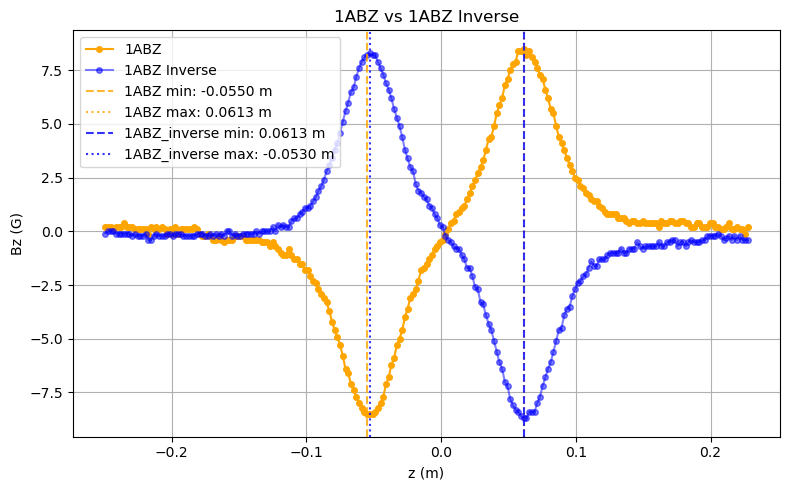

In [5]:
# Positions where each dataset reaches its minimum and maximum
z_1ABZ_min = z_1ABZ[B_1ABZ.idxmin()]
z_1ABZ_max = z_1ABZ[B_1ABZ.idxmax()]

z_1ABZ_inverse_min = z_1ABZ_inverse[B_1ABZ_inverse.idxmin()]
z_1ABZ_inverse_max = z_1ABZ_inverse[B_1ABZ_inverse.idxmax()]

plt.figure(figsize=(8, 5))

plt.plot(
    z_1ABZ,
    B_1ABZ,
    marker="o",
    markersize=4,
    color="orange",
    label="1ABZ"
)

plt.plot(
    z_1ABZ_inverse,
    B_1ABZ_inverse,
    marker="o",
    markersize=4,
    color="blue",
    alpha=0.5,
    label="1ABZ Inverse"
)

# Vertical lines for 1ABZ
plt.axvline(
    z_1ABZ_min,
    color="orange",
    linestyle="--",
    alpha=0.8,
    label=f"1ABZ min: {z_1ABZ_min:.4f} m"
)

plt.axvline(
    z_1ABZ_max,
    color="orange",
    linestyle=":",
    alpha=0.8,
    label=f"1ABZ max: {z_1ABZ_max:.4f} m"
)

# Vertical lines for 3ABZ
plt.axvline(
    z_1ABZ_inverse_min,
    color="blue",
    linestyle="--",
    alpha=0.8,
    label=f"1ABZ_inverse min: {z_1ABZ_inverse_min:.4f} m"
)

plt.axvline(
    z_1ABZ_inverse_max,
    color="blue",
    linestyle=":",
    alpha=0.8,
    label=f"1ABZ_inverse max: {z_1ABZ_inverse_max:.4f} m"
)

plt.xlabel("z (m)")
plt.ylabel("Bz (G)")
plt.title("1ABZ vs 1ABZ Inverse")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# B field, Bottom and Top coils

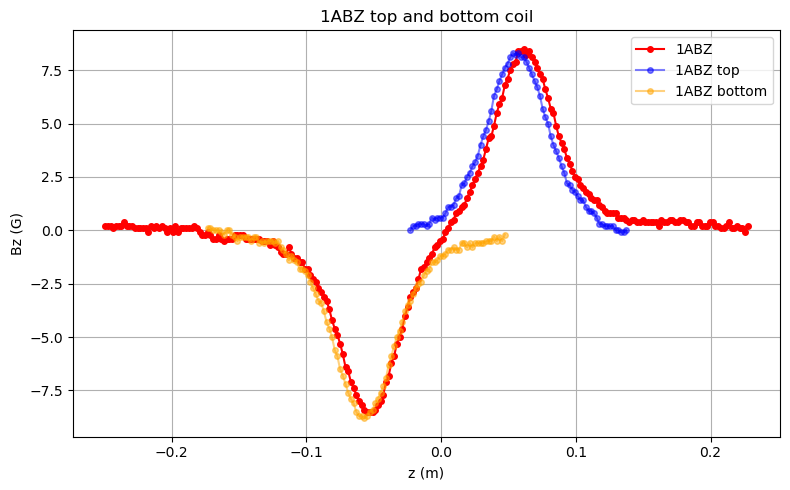

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    z_1ABZ,
    B_1ABZ,
    marker="o",
    markersize=4,
    color="red",
    label="1ABZ"
)

plt.plot(
    z_1ABZ_top,
    B_1ABZ_top,
    marker="o",
    markersize=4,
    color="blue",
    alpha=0.5,
    label="1ABZ top"
)

plt.plot(
    z_1ABZ_bottom,
    B_1ABZ_bottom,
    marker="o",
    markersize=4,
    color="orange",
    alpha=0.5,
    label="1ABZ bottom"
)

plt.xlabel("z (m)")
plt.ylabel("Bz (G)")
plt.title("1ABZ top and bottom coil")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparison 1A and 3A

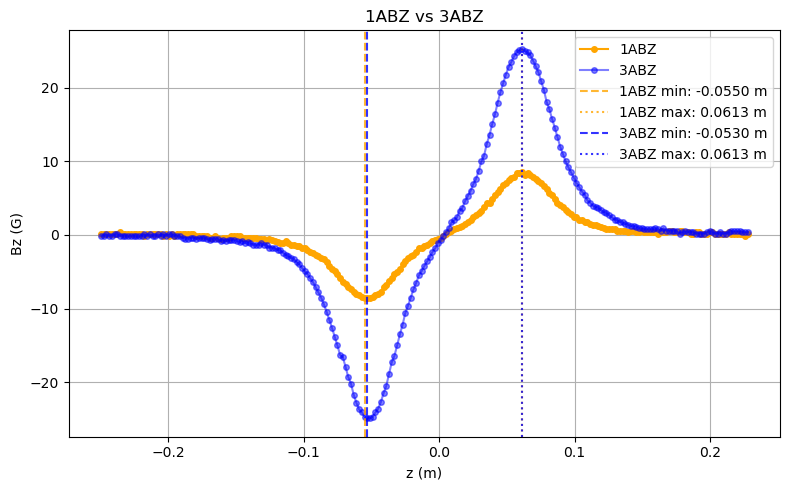

In [7]:
# Positions where each dataset reaches its minimum and maximum
z_1ABZ_min = z_1ABZ[B_1ABZ.idxmin()]
z_1ABZ_max = z_1ABZ[B_1ABZ.idxmax()]

z_3ABZ_min = z_3ABZ[B_3ABZ.idxmin()]
z_3ABZ_max = z_3ABZ[B_3ABZ.idxmax()]

plt.figure(figsize=(8, 5))

plt.plot(
    z_1ABZ,
    B_1ABZ,
    marker="o",
    markersize=4,
    color="orange",
    label="1ABZ"
)

plt.plot(
    z_3ABZ,
    B_3ABZ,
    marker="o",
    markersize=4,
    color="blue",
    alpha=0.5,
    label="3ABZ "
)

# Vertical lines for 1ABZ
plt.axvline(
    z_1ABZ_min,
    color="orange",
    linestyle="--",
    alpha=0.8,
    label=f"1ABZ min: {z_1ABZ_min:.4f} m"
)

plt.axvline(
    z_1ABZ_max,
    color="orange",
    linestyle=":",
    alpha=0.8,
    label=f"1ABZ max: {z_1ABZ_max:.4f} m"
)

# Vertical lines for 3ABZ
plt.axvline(
    z_3ABZ_min,
    color="blue",
    linestyle="--",
    alpha=0.8,
    label=f"3ABZ min: {z_3ABZ_min:.4f} m"
)

plt.axvline(
    z_3ABZ_max,
    color="blue",
    linestyle=":",
    alpha=0.8,
    label=f"3ABZ max: {z_3ABZ_max:.4f} m"
)


plt.xlabel("z (m)")
plt.ylabel("Bz (G)")
plt.title("1ABZ vs 3ABZ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
B_min = B_1ABX.min()
B_max = B_1ABX.max()

# All indices where the minimum and maximum occur
min_indices = B_1ABX.index[np.isclose(B_1ABX, B_min)]
max_indices = B_1ABX.index[np.isclose(B_1ABX, B_max)]

print("Minimum indices:", min_indices.tolist())
print("Maximum indices:", max_indices.tolist())

print("x positions for the minimum:")
print(x_1ABX.loc[min_indices])

print("x positions for the maximum:")
print(x_1ABX.loc[max_indices])

selected_min_index = min_indices[1]
x_1ABX_min = x_1ABX.loc[selected_min_index]

Minimum indices: [148, 150, 152]
Maximum indices: [82, 84, 86, 87, 88, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102]
x positions for the minimum:
148    0.032742
150    0.036751
152    0.040760
Name: x(m), dtype: float64
x positions for the maximum:
82    -0.045428
84    -0.043424
86    -0.041419
87    -0.040417
88    -0.039415
90    -0.037411
92    -0.035406
93    -0.034404
94    -0.033402
95    -0.032400
96    -0.031398
97    -0.030395
98    -0.029393
99    -0.028391
100   -0.027389
102   -0.025385
Name: x(m), dtype: float64


# Bx Field

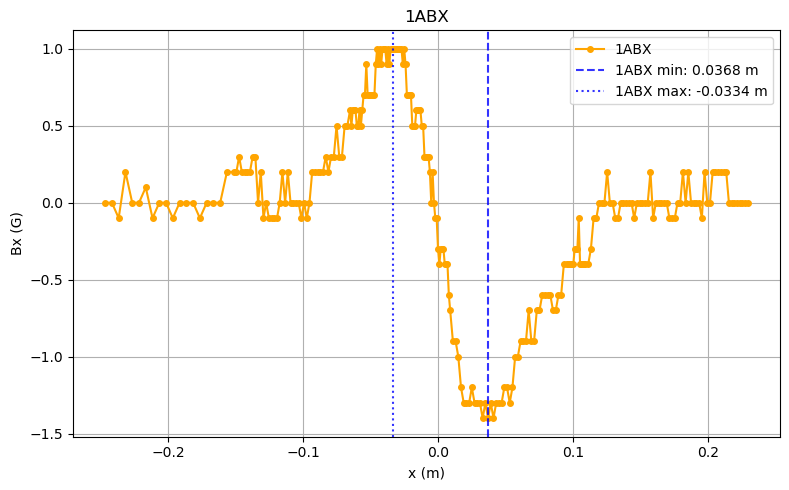

In [9]:
selected_min_index = min_indices[1]
selected_max_index = max_indices[8]

x_1ABX_min = x_1ABX.loc[selected_min_index]
x_1ABX_max = x_1ABX.loc[selected_max_index]

plt.figure(figsize=(8, 5))

plt.plot(
    x_1ABX,
    B_1ABX,
    marker="o",
    markersize=4,
    color="orange",
    label="1ABX"
)

# Vertical lines 
plt.axvline(
    x_1ABX_min,
    color="blue",
    linestyle="--",
    alpha=0.8,
    label=f"1ABX min: {x_1ABX_min:.4f} m"
)

plt.axvline(
    x_1ABX_max,
    color="blue",
    linestyle=":",
    alpha=0.8,
    label=f"1ABX max: {x_1ABX_max:.4f} m"
)


plt.xlabel("x (m)")
plt.ylabel("Bx (G)")
plt.title("1ABX")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Bx Gradient

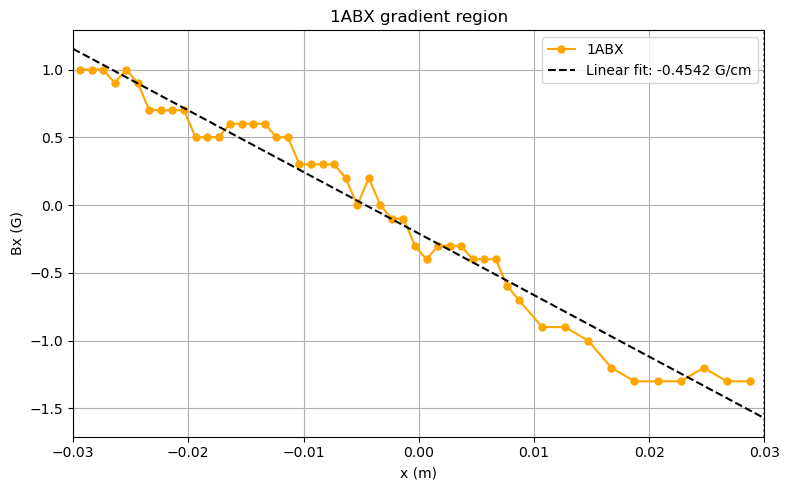

Gradient = -45.4231 G/m
Gradient = -0.4542 G/cm
Intercept = -0.2099 G


In [10]:

# Region for the gradient calculation
x_min_region = -0.03
x_max_region = 0.03


# Select only the points inside the region
mask = (
    (x_1ABX >= x_min_region)
    & (x_1ABX <= x_max_region)
)

x_region = x_1ABX[mask].to_numpy()
B_region = B_1ABX[mask].to_numpy()

# Linear fit: Bx(x) = gradient*x + intercept
gradient, intercept = np.polyfit(
    x_region,
    B_region,
    1
)

# Fitted line
x_fit = np.linspace(
    x_min_region,
    x_max_region,
    200
)

B_fit = gradient * x_fit + intercept


plt.figure(figsize=(8, 5))


# Data used for the gradient
plt.plot(
    x_region,
    B_region,
    marker="o",
    markersize=5,
    color="orange",
    label="1ABX"
)

# Linear fit
plt.plot(
    x_fit,
    B_fit,
    color="black",
    linestyle="--",
    label=f"Linear fit: {gradient / 100:.4f} G/cm"
)

# Limits of the selected region
plt.axvline(
    x_min_region,
    color="gray",
    linestyle=":"
)

plt.axvline(
    x_max_region,
    color="gray",
    linestyle=":"
)

# Show only the selected region
plt.xlim(x_min_region, x_max_region)

plt.xlabel("x (m)")
plt.ylabel("Bx (G)")
plt.title("1ABX gradient region")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Gradient = {gradient:.4f} G/m")
print(f"Gradient = {gradient / 100:.4f} G/cm")
print(f"Intercept = {intercept:.4f} G")

# Bz Field

In [21]:
B_min_z = B_1ABZ_close.min()
B_max_z = B_1ABZ_close.max()

# All indices where the minimum and maximum occur
min_indices_z = B_1ABZ_close.index[np.isclose(B_1ABZ_close, B_min_z)]
max_indices_z = B_1ABZ_close.index[np.isclose(B_1ABZ_close, B_max_z)]

print("Minimum indices:", min_indices_z.tolist())
print("Maximum indices:", max_indices_z.tolist())

print("x positions for the minimum:")
print(z_1ABZ_close.loc[min_indices_z])

print("x positions for the maximum:")
print(z_1ABZ_close.loc[max_indices_z])

selected_min_index = min_indices_z[0]
z_1ABZ_min = z_1ABZ.loc[selected_min_index]

Minimum indices: [143]
Maximum indices: [252, 254, 255, 256]
x positions for the minimum:
143   -0.053973
Name: z(m), dtype: float64
x positions for the maximum:
252    0.055264
254    0.057269
255    0.058271
256    0.059273
Name: z(m), dtype: float64


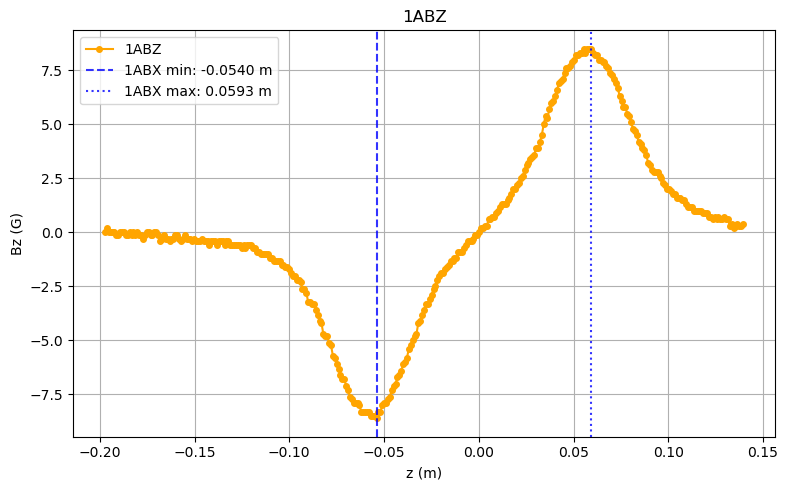

In [25]:
selected_min_index = min_indices_z[0]
selected_max_index = max_indices_z[3]


z_1ABZ_min = z_1ABZ_close.loc[selected_min_index]
z_1ABZ_max = z_1ABZ_close.loc[selected_max_index]


plt.figure(figsize=(8, 5))

plt.plot(
    z_1ABZ_close,
    B_1ABZ_close,
    marker="o",
    markersize=4,
    color="orange",
    label="1ABZ"
)

# Vertical lines 
plt.axvline(
    z_1ABZ_min,
    color="blue",
    linestyle="--",
    alpha=0.8,
    label=f"1ABX min: {z_1ABZ_min:.4f} m"
)

plt.axvline(
    z_1ABZ_max,
    color="blue",
    linestyle=":",
    alpha=0.8,
    label=f"1ABX max: {z_1ABZ_max:.4f} m"
)


plt.xlabel("z (m)")
plt.ylabel("Bz (G)")
plt.title("1ABZ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Bz gradient 

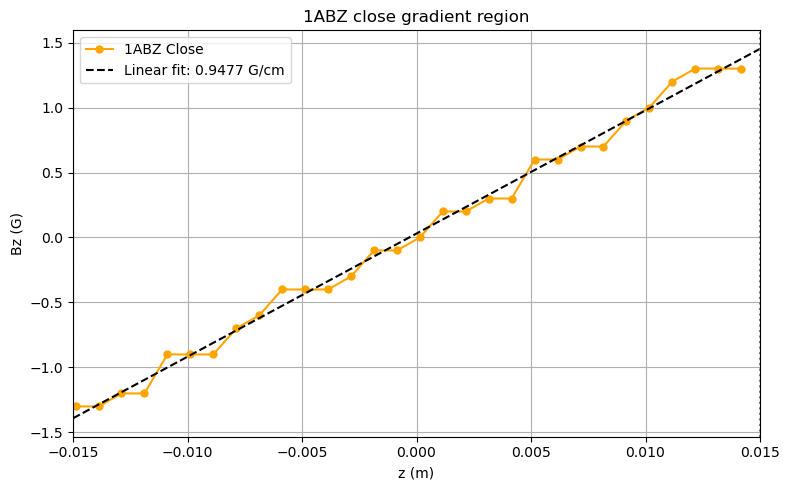

Gradient = 94.7654 G/m
Gradient = 0.9477 G/cm
Intercept = 0.0305 G


In [28]:
# Region for the gradient calculation
z_min_region = -0.015
z_max_region = 0.015


# Select only the points inside the region
mask = (
    (z_1ABZ_close >= z_min_region)
    & (z_1ABZ_close <= z_max_region)
)

z_region = z_1ABZ_close[mask].to_numpy()
Bz_region = B_1ABZ_close[mask].to_numpy()

# Linear fit: Bz(z) = gradient*z + intercept
gradient, intercept = np.polyfit(
    z_region,
    Bz_region,
    1
)

# Fitted line
z_fit = np.linspace(
    z_min_region,
    z_max_region,
    200
)

Bz_fit = gradient * z_fit + intercept


plt.figure(figsize=(8, 5))


# Data used for the gradient
plt.plot(
    z_region,
    Bz_region,
    marker="o",
    markersize=5,
    color="orange",
    label="1ABZ Close"
)

# Linear fit
plt.plot(
    z_fit,
    Bz_fit,
    color="black",
    linestyle="--",
    label=f"Linear fit: {gradient / 100:.4f} G/cm"
)

# Limits of the selected region
plt.axvline(
    z_min_region,
    color="gray",
    linestyle=":"
)

plt.axvline(
    z_max_region,
    color="gray",
    linestyle=":"
)

# Show only the selected region
plt.xlim(z_min_region, z_max_region)

plt.xlabel("z (m)")
plt.ylabel("Bz (G)")
plt.title("1ABZ close gradient region")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Gradient = {gradient:.4f} G/m")
print(f"Gradient = {gradient / 100:.4f} G/cm")
print(f"Intercept = {intercept:.4f} G")